# Ragas Testing

In [1]:
import os 
import json 
from datasets import Dataset
from ragas import evaluate
from ragas.metrics import faithfulness, answer_correctness


ModuleNotFoundError: No module named 'ragas'

In [ ]:
def pretty_print_json(data):
    print(json.dumps(data, indent=4))


def load_json(file_path):
    '''
    '''
    with open(file_path, encoding="utf-8") as f:
        data = json.load(f)
        return data


dataset_path = 'data/ucd_studentdesk_faqs.json'
data = load_json(dataset_path)

pretty_print_json(data[0])

{
    "section": "UCD Connect",
    "question": "How do I log in to UCD IT Systems including SISWeb, Brightspace or UCD Email?",
    "answer_text": "Log in by selecting Current Student or All Other Users . Current Students use their @ucdconnect.ie email; All Other Users use their username (i.e. student number). If you do not know your student number, please AskUs. Password = 6-digit DOB (DDMMYY) unless \u200byou changed\u200b it. Full info below: When accessing UCD IT Systems, users will see a splash screen with two buttons: \"Current Students\" and \"All Other Users\". For Current Students Once Current Students is selected from the screen, students will log in using their @ucdconnect.ie email address rather than their UCD Connect Username. After entering the email address and clicking next, there will be a second prompt for the password to be entered. For All Others Users (including Alumni and Applicants) Once All Other Users is selected from the screen shown above, all other users wi

In [ ]:
print(f'{data[0]["section"]} - {data[0]["question"]}:')
print(data[0]['answer_text'])

UCD Connect - How do I log in to UCD IT Systems including SISWeb, Brightspace or UCD Email?:
Log in by selecting Current Student or All Other Users . Current Students use their @ucdconnect.ie email; All Other Users use their username (i.e. student number). If you do not know your student number, please AskUs. Password = 6-digit DOB (DDMMYY) unless ​you changed​ it. Full info below: When accessing UCD IT Systems, users will see a splash screen with two buttons: "Current Students" and "All Other Users". For Current Students Once Current Students is selected from the screen, students will log in using their @ucdconnect.ie email address rather than their UCD Connect Username. After entering the email address and clicking next, there will be a second prompt for the password to be entered. For All Others Users (including Alumni and Applicants) Once All Other Users is selected from the screen shown above, all other users will proceed to the username and password screen where you log in using 

In [ ]:
data_samples = {
    'question': [
        'When was the first super bowl?', 
        'Who won the most super bowls?'
    ],
    'answer': [
        'The first superbowl was held on Jan 15, 1967', 
        'The most super bowls have been won by The New England Patriots'
    ],
    'contexts': [
        [
            'The First AFL–NFL World Championship Game was an American football game played on January 15, 1967, at the Los Angeles Memorial Coliseum in Los Angeles,'
        ], 
        [
            'The Green Bay Packers...Green Bay, Wisconsin.',
            'The Packers compete...Football Conference'
        ]
    ],
    'ground_truth': [
        'The first superbowl was held on January 15, 1967', 
        'The New England Patriots have won the Super Bowl a record six times'
    ]
}

In [ ]:
# from ragas.llms import llm_factory
# from openai import OpenAI
# import os

# # Load API key from private JSON
# keys_json = load_json('data/keys.json')
# os.environ["OPENAI_API_KEY"] = keys_json['OpenAI']

# client = OpenAI()
# llm = llm_factory("gpt-4o", client=client)


In [ ]:
# from datasets import Dataset
# from ragas import evaluate
# from ragas.metrics import faithfulness, answer_correctness
# from ragas.embeddings import OpenAIEmbeddings

# dataset = Dataset.from_dict(data_samples)

# embeddings = OpenAIEmbeddings(client=client)

# score = evaluate(
#     dataset,
#     metrics=[faithfulness, answer_correctness],
#     llm=llm,
#     embeddings=embeddings
# )

# df = score.to_pandas()
# df.to_csv("score.csv", index=False)
# print(df)

C:\Users\eoinm\AppData\Local\Temp\ipykernel_22748\118293279.py:3: DeprecationWarning: Importing faithfulness from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import faithfulness
  from ragas.metrics import faithfulness, answer_correctness
C:\Users\eoinm\AppData\Local\Temp\ipykernel_22748\118293279.py:3: DeprecationWarning: Importing answer_correctness from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import answer_correctness
  from ragas.metrics import faithfulness, answer_correctness


Evaluating:   0%|          | 0/4 [00:00<?, ?it/s]

Exception raised in Job[0]: InstructorRetryException(<failed_attempts>

<generation number="1">
<exception>
    Error code: 429 - {'error': {'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, read the docs: https://platform.openai.com/docs/guides/error-codes/api-errors.', 'type': 'insufficient_quota', 'param': None, 'code': 'insufficient_quota'}}
</exception>
<completion>
    None
</completion>
</generation>

<generation number="2">
<exception>
    Error code: 429 - {'error': {'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, read the docs: https://platform.openai.com/docs/guides/error-codes/api-errors.', 'type': 'insufficient_quota', 'param': None, 'code': 'insufficient_quota'}}
</exception>
<completion>
    None
</completion>
</generation>

<generation number="3">
<exception>
    Error code: 429 - {'error': {'message': 'You exceeded your

                       user_input  \
0  When was the first super bowl?   
1   Who won the most super bowls?   

                                  retrieved_contexts  \
0  [The First AFL–NFL World Championship Game was...   
1  [The Green Bay Packers...Green Bay, Wisconsin....   

                                            response  \
0       The first superbowl was held on Jan 15, 1967   
1  The most super bowls have been won by The New ...   

                                           reference  faithfulness  \
0   The first superbowl was held on January 15, 1967           NaN   
1  The New England Patriots have won the Super Bo...           NaN   

   answer_correctness  
0                 NaN  
1                 NaN  


In [5]:
import os, json
from datetime import datetime
from datasets import Dataset

from openai import OpenAI
from ragas.llms import llm_factory

from ragas.run_config import RunConfig
from ragas import evaluate as ragas_evaluate
# from ragas.metrics.collections import Faithfulness, AnswerCorrectness
from ragas.metrics import faithfulness, answer_correctness
#answer_relevancy, context_precision, context_recall, context_utilization

from langchain_community.llms import Ollama
from langchain_community.embeddings import OllamaEmbeddings

# Optional OpenAI path
from openai import OpenAI
from ragas.llms import llm_factory
from ragas.embeddings import OpenAIEmbeddings


def create_folder(path: str):
    os.makedirs(path, exist_ok=True)


def openai_embedding_loader(client: OpenAI, model: str = "text-embedding-3-small"):
    return OpenAIEmbeddings(client=client, model=model)


def ollama_embedding_loader(model: str):
    return OllamaEmbeddings(model=model)


''' Embedding registry
    Good Ollama embeddings:
        * ollama pull mxbai-embed-large
        * ollama pull nomic-embed-text
        * ollama pull all-minilm
'''
EMBEDDING_LOADERS = {
    # Ollama embeddings
    "nomic-embed-text": lambda _client=None: ollama_embedding_loader("nomic-embed-text"),
    "mxbai-embed-large": lambda _client=None: ollama_embedding_loader("mxbai-embed-large"),
    "all-minilm": lambda _client=None: ollama_embedding_loader("all-minilm"),
    "none": lambda _client=None: None,
    # OpenAI embeddings (if you ever use them)
    "text-embedding-3-small": lambda client: openai_embedding_loader(client, "text-embedding-3-small"),
    "text-embedding-3-large": lambda client: openai_embedding_loader(client, "text-embedding-3-large"),
}


class ResultsEvaluation:
    def __init__(self, dataset_path: str, llm_load_type: str, llm_model: str, openai_api_key: str | None = None):
        self.dataset_path = dataset_path
        self.dataset = self.load_dataset(dataset_path)

        self.llm_load_type = llm_load_type
        self.llm_model = llm_model

        self.client = None
        if openai_api_key:
            os.environ["OPENAI_API_KEY"] = openai_api_key
            self.client = OpenAI()

        self.eval_llm = self.load_llm()



    def load_dataset(self, dataset_path: str) -> Dataset:
        with open(dataset_path, "r", encoding="utf-8") as f:
            data = json.load(f)
        # pretty_print_json(data)
        return Dataset.from_dict(data)


    def load_llm(self):
        if self.llm_load_type == "local":
            # Talk to your LOCAL Ollama via its OpenAI-compatible API (no OpenAI credits)
            self.client = OpenAI(
                api_key="ollama",  # dummy
                base_url="http://localhost:11434/v1"
            )
            return llm_factory(
                self.llm_model,          # e.g. "phi3:mini"
                provider="openai",       # ollama mimics OpenAI API
                client=self.client
            )

        if self.llm_load_type == "client":
            if self.client is None:
                self.client = OpenAI()
            return llm_factory(self.llm_model, client=self.client)

        raise ValueError("llm_load_type must be 'local' or 'client'")



    def run(self, embedding_model: str = "nomic-embed-text", out_dir: str = "data/experiments/"):
        if embedding_model not in EMBEDDING_LOADERS:
            raise ValueError(f"Unknown embedding model: {embedding_model}")

        embeddings = EMBEDDING_LOADERS[embedding_model](self.client)
        
        '''
            faithfulness
            answer_correctness
            answer_relevancy
            context_precision
            context_recall
            context_utilization
        '''
        # Adding this to stop getting 429 error codes & force sequential execution
        run_config = RunConfig(
            max_workers=1,   # prevent parallel hammering
            max_retries=5
        )

        score = ragas_evaluate(
            dataset=self.dataset,
            metrics=[faithfulness, answer_correctness],
            llm=self.eval_llm,
            embeddings=embeddings,
            run_config=run_config,
            column_map={
                "question": "question",
                "answer": "answer",
                "contexts": "contexts",
                "reference": "ground_truths",
            },
            raise_exceptions=True, 
        )

        df = score.to_pandas()
        timestamp = datetime.now().strftime("%d_%m_%Y_%H_%M_%S")
        create_folder(out_dir)

        safe_llm = str(self.llm_model).replace("/", "-").replace(":", "-")
        safe_load = self.llm_load_type
        safe_emb = embedding_model.replace("/", "-").replace(":", "-")

        out_path = f"{out_dir}{timestamp}_{safe_llm}_{safe_load}_{safe_emb}.csv"
        df.to_csv(out_path, index=False)
        return out_path, df
    


# NOTE - Build this out after
# ExperimentConfig(
#     llm="llama3.2:3b",
#     embeddings="nomic-embed-text",
#     top_k=5,
#     chunk_size=500,
# )


reval = ResultsEvaluation(
    dataset_path="data/test_samples.json",
    llm_load_type="local",
    # llm_model="llama3.2:3b",
    # llm_model="phi3:mini"
    llm_model="llama3.2:3b"
)

out_path, df = reval.run(embedding_model="mxbai-embed-large")
print("Saved:", out_path)
print(df.head())

C:\Users\eoinm\AppData\Local\Temp\ipykernel_21516\3984530404.py:11: DeprecationWarning: Importing faithfulness from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import faithfulness
  from ragas.metrics import faithfulness, answer_correctness
C:\Users\eoinm\AppData\Local\Temp\ipykernel_21516\3984530404.py:11: DeprecationWarning: Importing answer_correctness from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import answer_correctness
  from ragas.metrics import faithfulness, answer_correctness


Evaluating:   0%|          | 0/4 [00:00<?, ?it/s]

Saved: data/experiments/25_02_2026_17_19_08_llama3.2-3b_local_mxbai-embed-large.csv
                       user_input  \
0  When was the first super bowl?   
1   Who won the most super bowls?   

                                  retrieved_contexts  \
0  [The First AFL–NFL World Championship Game was...   
1  [The Green Bay Packers...Green Bay, Wisconsin....   

                                            response  \
0       The first superbowl was held on Jan 15, 1967   
1  The most super bowls have been won by The New ...   

                                           reference  faithfulness  \
0   The first superbowl was held on January 15, 1967           0.0   
1  The New England Patriots have won the Super Bo...           0.0   

   answer_correctness  
0            0.999894  
1            0.744532  


## RAGAS results and visualizations

This cell reads the evaluation results from the JSON configuration file and converts them into a  pd.DataFrame.

Also writes out a combined CSV file and one CSV per experiment so the rest of the notebook can analyse the results in a format that matches a typical evaluation workflow.


In [10]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import json

results_dir = Path('ragas_results')
results_dir.mkdir(exist_ok=True)

CONFIG_PATH = 'C:/Users/eoinm/masters/group_assignments/semester-2/COMP41860-dashboard/backend/ragas_results/ragas_config_results.json'


def build_ragas_results_from_json(results_dir: Path, config_path: str):
    """Build RAGAS results DF from JSON file"""

    with open(config_path, "r") as f:
        config = json.load(f)

    rows = []

    for exp in config["experiments"]:
        for r in exp["results"]:
            rows.append({
                "experiment_name": exp["experiment_name"],
                "question": r["question"],
                "faithfulness": r["faithfulness"],
                "answer_correctness": r["answer_correctness"],
                "answer_relevancy": r["answer_relevancy"],
                "context_precision": r["context_precision"],
                "context_recall": r["context_recall"],
                "latency_ms": r["latency_ms"],
                "llm_model": exp["llm_model"],
                "embedding_model": exp["embedding_model"],
                "retriever_k": exp["retriever_k"],
            })

    df = pd.DataFrame(rows)

    # Save combined results
    df.to_csv(results_dir / 'all_ragas_results.csv', index=False)

    # Save per experiment
    for exp_name, exp_df in df.groupby("experiment_name"):
        exp_df.to_csv(results_dir / f"{exp_name}.csv", index=False)

    return df


# Run
ragas_df = build_ragas_results_from_json(results_dir, CONFIG_PATH)

### Load the results table

Loads the combined RAGAS results into a DataFrame. Each row represents one question evaluated under one experiment configuration, with columns for the main RAGAS metrics, latency, and metadata such as the LLM, embedding model, and retrieval settings.

In [11]:
# Load the consolidated results
df = pd.read_csv(results_dir / 'all_ragas_results.csv')
df.head()


,experiment_name,question,faithfulness,answer_correctness,answer_relevancy,context_precision,context_recall,latency_ms,llm_model,embedding_model,retriever_k
0,voyageai_512_64_basic_dense_False,How do I log in to UCD IT Systems including SI...,0.697,0.711,0.649,0.604,0.544,1861,llama3.2:3b,nomic-embed-text,4
1,voyageai_512_64_basic_dense_False,What is SISWeb? What is Brightspace?,0.766,0.705,0.712,0.632,0.624,1933,llama3.2:3b,nomic-embed-text,4
2,voyageai_512_64_basic_dense_False,How do I reset my password?,0.627,0.731,0.685,0.645,0.499,1586,llama3.2:3b,nomic-embed-text,4
3,voyageai_512_64_basic_dense_False,How do I contact IT Support Hub?,0.666,0.652,0.675,0.618,0.631,1784,llama3.2:3b,nomic-embed-text,4
4,voyageai_512_64_basic_dense_False,Will I lose access to SISWeb when I graduate o...,0.725,0.704,0.627,0.706,0.633,2115,llama3.2:3b,nomic-embed-text,4


### Compute experiment level summary metrics

This cell aggregates the per-question results to the experiment level by taking the mean score for each metric. The resulting summary table makes it easier to compare overall system performance across the different RAG configurations.

In [12]:
metric_cols = [
    "faithfulness",
    "answer_correctness",
    "answer_relevancy",
    "context_precision",
    "context_recall",
]

summary_df = (
    df.groupby("experiment_name")[metric_cols + ["latency_ms"]]
      .mean()
      .sort_values("answer_correctness", ascending=False)
      .round(3)
)
summary_df


,faithfulness,answer_correctness,answer_relevancy,context_precision,context_recall,latency_ms
experiment_name,,,,,,
voyageai_512_64_contextual_hybrid_True,0.863,0.834,0.809,0.779,0.762,1697.3
voyageai_512_64_basic_dense_False,0.707,0.680,0.662,0.622,0.606,1901.5


### Compare AVG performance across experiments

This plot shows the mean value of each RAGAS metric for every experiment. It provides a high-level comparison of overall system quality and helps identify which configuration performs best across faithfulness, correctness, relevancy, and retrieval quality.

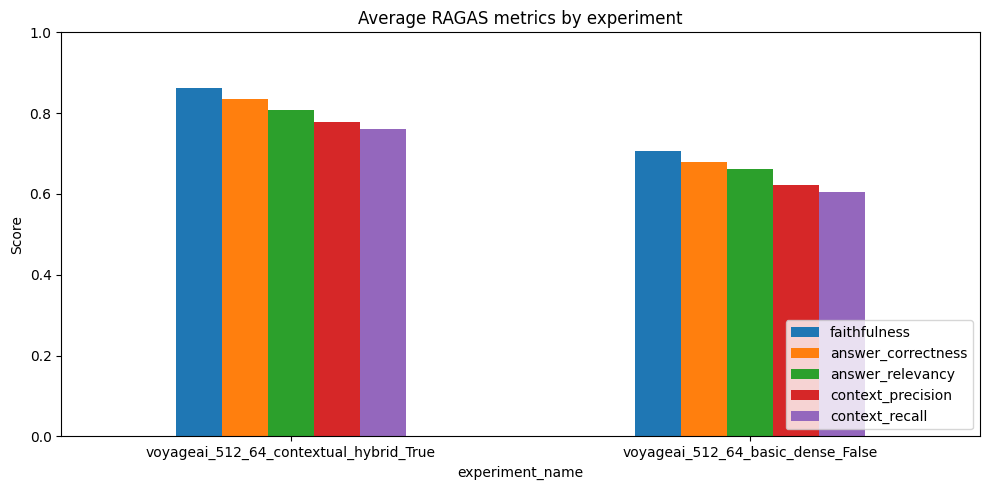

In [13]:
ax = summary_df[metric_cols].plot(kind="bar", figsize=(10, 5))
ax.set_title("Average RAGAS metrics by experiment")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
ax.legend(loc="lower right")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Visualise each metric separately

One bar chart per metric

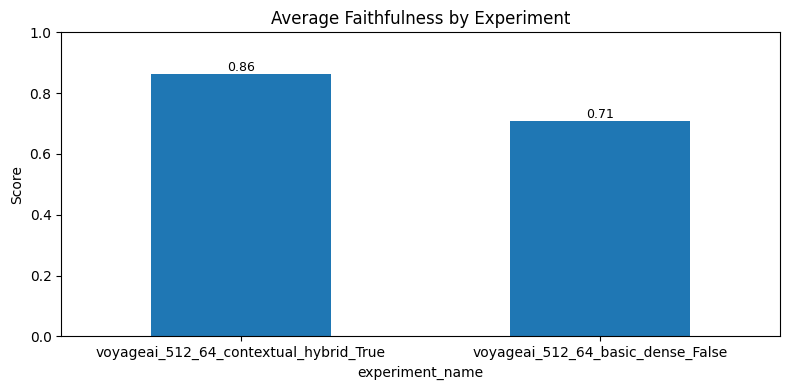

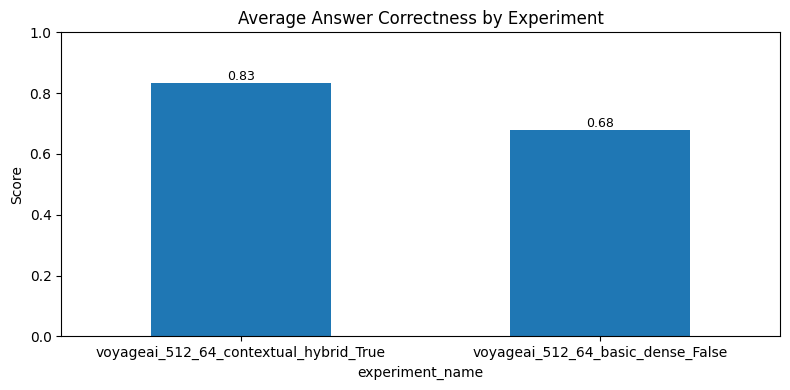

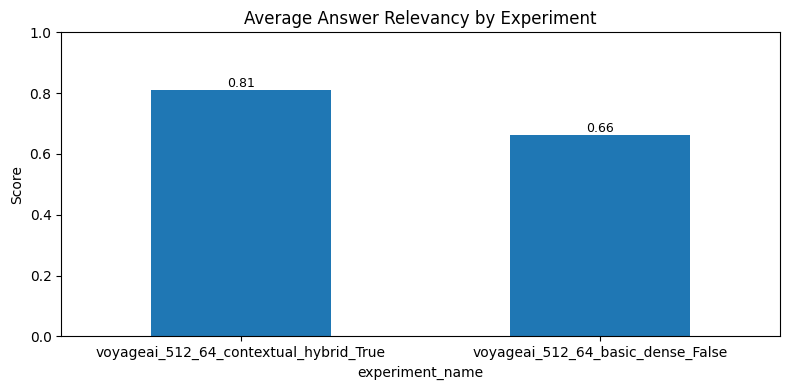

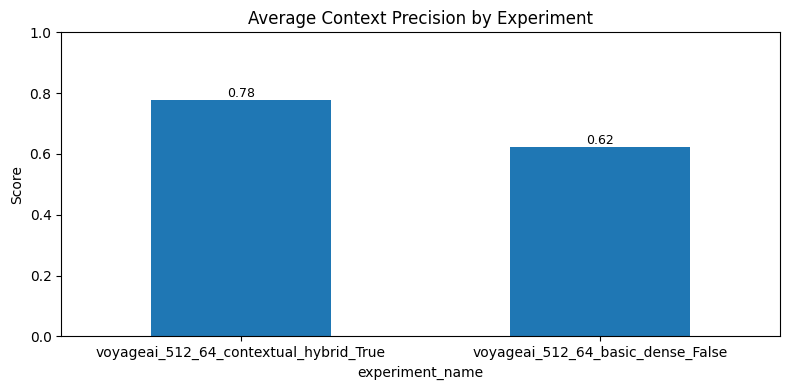

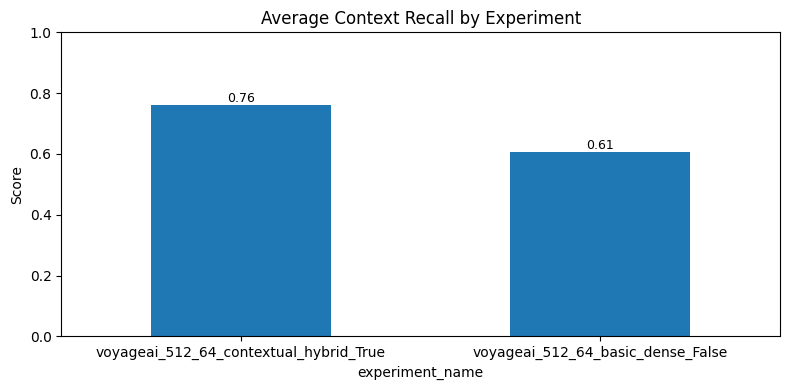

In [14]:
for metric in metric_cols:
    ax = summary_df[[metric]].plot(kind="bar", figsize=(8, 4), legend=False)
    
    for p in ax.patches:
        ax.annotate(
            f"{p.get_height():.2f}",
            (p.get_x() + p.get_width() / 2, p.get_height()),
            ha='center',
            va='bottom',
            fontsize=9
        )
    
    ax.set_title(f"Average {metric.replace('_', ' ').title()} by Experiment")
    ax.set_ylabel("Score")
    ax.set_ylim(0, 1)
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

### Examine score distributions, not just averages

Average values can hide variation, so this cell uses boxplots to show how faithfulness and answer correctness are distributed across questions for each experiment. This helps reveal consistency, spread, and potential outlier behaviour in the results.

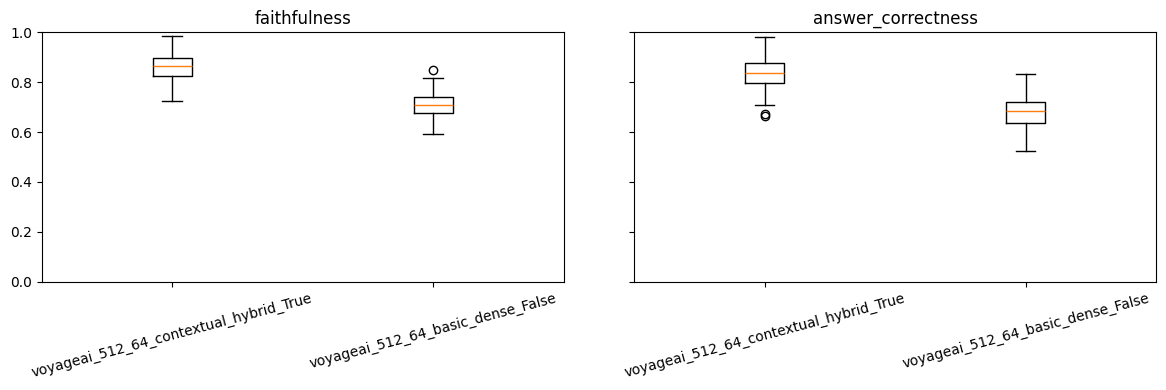

In [15]:
plot_df = df[["experiment_name", "faithfulness", "answer_correctness"]].copy()
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, metric in zip(axes, ["faithfulness", "answer_correctness"]):
    grouped = [plot_df.loc[plot_df["experiment_name"] == exp, metric].values for exp in summary_df.index]
    ax.boxplot(grouped, tick_labels=list(summary_df.index))
    ax.set_title(metric)
    ax.set_ylim(0, 1)
    ax.tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.show()


### Explore the relationship between faithfulness and correctness

This scatter plot compares faithfulness and answer correctness at the question level. It helps show whether strong factual grounding tends to coincide with correct answers, and whether any experiments produce cases that are correct but not well grounded, or grounded but still incomplete.

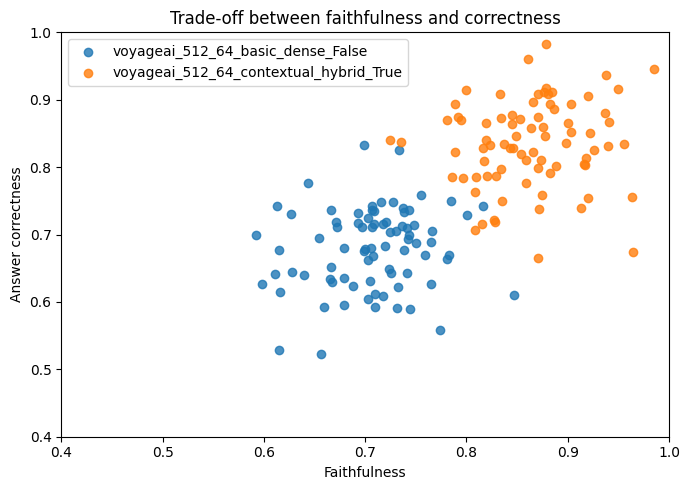

In [16]:
fig, ax = plt.subplots(figsize=(7, 5))
for exp_name, exp_df in df.groupby("experiment_name"):
    ax.scatter(exp_df["faithfulness"], exp_df["answer_correctness"], label=exp_name, alpha=0.8)
ax.set_xlabel("Faithfulness")
ax.set_ylabel("Answer correctness")
ax.set_xlim(0.4, 1.0)
ax.set_ylim(0.4, 1.0)
ax.set_title("Trade-off between faithfulness and correctness")
ax.legend()
plt.tight_layout()
plt.show()


### Compare experiments question by question

This cell reshapes the results into a per-question comparison table for the two main evaluation metrics. It is useful for spotting which questions are consistently handled well, which ones are difficult across all experiments, and where one configuration clearly outperforms another.

In [17]:
question_view = (
    df.pivot_table(
        index="question",
        columns="experiment_name",
        values=["faithfulness", "answer_correctness"],
        aggfunc="mean",
    )
    .round(3)
)
question_view.head(10)


answer_correctness  \
experiment_name                                    voyageai_512_64_basic_dense_False   
question                                                                               
Applying to the Teaching Council?                                              0.669   
Are UK applicants still eligible for EU Fees?                                  0.643   
Are final results for all programmes available ...                             0.640   
Are my Electronic Documents available to me thr...                             0.717   
Can I change my first name under the Gender ID ...                             0.825   
Can I check a hold on my record?                                               0.709   
Can I drop a module when online registration is...                             0.740   
Can I make a payment over the phone?                                           0.689   
Can I submit my thesis electronically?                                         0.693   
Can UCD email/scan my official documents to me ...                             0.590   

                                                                                           \
experiment_name                                    voyageai_512_64_contextual_hybrid_True   
question                                                                                    
Applying to the Teaching Council?                                                   0.916   
Are UK applicants still eligible for EU Fees?                                       0.799   
Are final results for all programmes available ...                                  0.859   
Are my Electronic Documents available to me thr...                                  0.835   
Can I change my first name under the Gender ID ...                                  0.865   
Can I check a hold on my record?                                                    0.886   
Can I drop a module when online registration is...                                  0.836   
Can I make a payment over the phone?                                                0.787   
Can I submit my thesis electronically?                                              0.893   
Can UCD email/scan my official documents to me ...                                  0.858   

                                                                        faithfulness  \
experiment_name                                    voyageai_512_64_basic_dense_False   
question                                                                               
Applying to the Teaching Council?                                              0.783   
Are UK applicants still eligible for EU Fees?                                  0.741   
Are final results for all programmes available ...                             0.640   
Are my Electronic Documents available to me thr...                             0.693   
Can I change my first name under the Gender ID ...                             0.733   
Can I check a hold on my record?                                               0.741   
Can I drop a module when online registration is...                             0.737   
Can I make a payment over the phone?                                           0.765   
Can I submit my thesis electronically?                                         0.742   
Can UCD email/scan my official documents to me ...                             0.744   

                                                                                           
experiment_name                                    voyageai_512_64_contextual_hybrid_True  
question                                                                                   
Applying to the Teaching Council?                                                   0.950  
Are UK applicants still eligible for EU Fees?                                       0.871  
Are final results for all programmes available ...                                  0.876  
Are my Electro

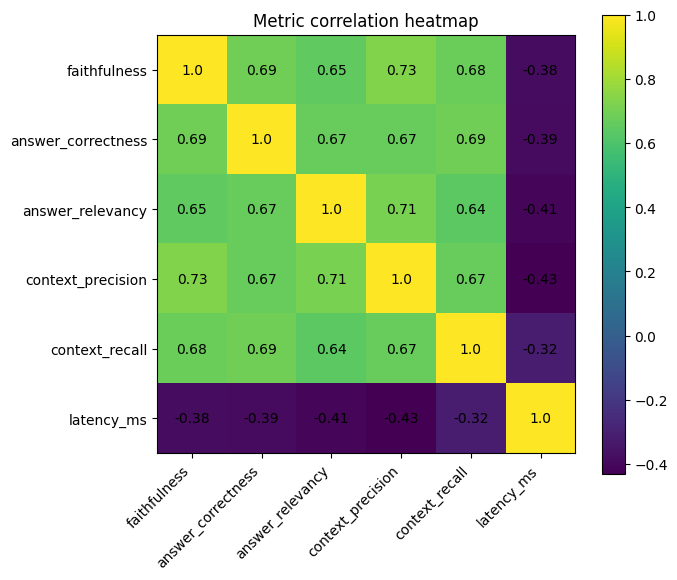

In [18]:
# 5) Quick correlation heatmap using matplotlib only
corr = df[metric_cols + ["latency_ms"]].corr().round(2)
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr.values)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.index)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticklabels(corr.index)
ax.set_title("Metric correlation heatmap")
for i in range(len(corr.index)):
    for j in range(len(corr.columns)):
        ax.text(j, i, corr.iloc[i, j], ha="center", va="center")
fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()
